# 1 ИМПОРТЫ НЕОБХОДИМЫХ БИБЛОТЕК И ЗАГРУЗКА ДАННЫХ

In [2980]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split




In [2981]:
# GDP_growth = pd.read_csv("../data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv", skiprows=4) # will seperate to Zambia and China_
GDP_per_capita = pd.read_csv("../data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv", skiprows=4)
exports = pd.read_csv("../data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_3934.csv", skiprows=4)
FDI_inflows = pd.read_csv("../data/API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv", skiprows = 4)
exchange_rate = pd.read_csv("../data/API_PA.NUS.FCRF_DS2_en_csv_v2_121619.csv", skiprows=4)
external_debt = pd.read_csv("../data/API_20_DS2_en_csv_v2_39106.csv", skiprows=4)
copper_prices = pd.read_excel("../data/CMO-Historical-Data-Annual.xlsx", sheet_name = "Annual Prices (Nominal)", skiprows=6)
percipitation = pd.read_csv("../data/API_AG.LND.PRCP.MM_DS2_en_csv_v2_7937.csv", skiprows=4)

# 2 ПРЕДОБРАБОТКА ПЕРЕМЕННЫХ

## 2.1 GDP_Zambia // GDP_china

In [2982]:
GDP_Zambia = GDP_per_capita[GDP_per_capita["Country Code"] == "ZMB"]
GDP_China = GDP_per_capita[GDP_per_capita["Country Name"] == "China"]
GDP_SA = GDP_per_capita[GDP_per_capita["Country Name"] == "South Africa"]
GDP_Switz = GDP_per_capita[GDP_per_capita["Country Name"] == "Switzerland"]


In [2983]:
GDP_China.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
40,China,CHN,GDP per capita (current US$),NY.GDP.PCAP.CD,89.715075,75.965501,71.061685,74.468154,85.661107,98.668169,...,8979.676527,10085.663815,10342.900952,10627.463799,12887.435724,12970.605641,12951.17824,13303.148154,NaN,NaN


In [2984]:
GDP_Switz.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
37,Switzerland,CHE,GDP per capita (current US$),NY.GDP.PCAP.CD,1954.311321,2155.449969,2330.477365,2508.474307,2734.93009,2865.244848,...,82254.376927,85217.369151,84121.93103,85897.784334,93664.77367,94394.51068,100623.549627,103998.186686,NaN,NaN


In [2985]:
GDP_SA.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
263,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6618.335083,6914.178032,6533.71121,5580.603831,6828.756246,6534.248678,6034.27209,6267.186814,NaN,NaN


Exclude Irrelevant columns

In [2986]:
GDP_China.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [2987]:
GDP_Zambia.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_China.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_SA.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_Switz.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [2988]:
GDP_Zambia.head()


,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,GDP per capita (current US$),221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,325.025847,340.57994,387.087289,...,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434,NaN


In [2989]:
GDP_Zambia = GDP_Zambia.T
GDP_China = GDP_China.T
GDP_SA = GDP_SA.T
GDP_Switz = GDP_Switz.T


In [2990]:
GDP_Zambia.head()

,264
Indicator Name,GDP per capita (current US$)
1960,221.559849
1961,209.693206
1962,202.281031
1963,203.219451


In [2991]:
GDP_China.head()

,40
Indicator Name,GDP per capita (current US$)
1960,89.715075
1961,75.965501
1962,71.061685
1963,74.468154


In [2992]:
GDP_SA.head()

,263
Indicator Name,GDP per capita (current US$)
1960,532.147504
1961,545.657512
1962,563.423009
1963,604.536855


In [2993]:
GDP_Switz.head()

,37
Indicator Name,GDP per capita (current US$)
1960,1954.311321
1961,2155.449969
1962,2330.477365
1963,2508.474307


Make first row headers

In [2994]:
new_header = GDP_Zambia.iloc[0] # grab the first row for the header
GDP_Zambia = GDP_Zambia[1:] # take the data less the header row
GDP_Zambia.columns = new_header
# GDP_Zambia.reset_index(drop = True, inplace=True)
new_header = GDP_China.iloc[0] # grab the first row for the header
GDP_China = GDP_China[1:] # take the data less the header row
GDP_China.columns = new_header

new_header = GDP_SA.iloc[0] # grab the first row for the header
GDP_SA = GDP_SA[1:] # take the data less the header row
GDP_SA.columns = new_header

new_header = GDP_Switz.iloc[0]
GDP_Switz = GDP_Switz[1:]
GDP_Switz.columns = new_header

In [2995]:
GDP_Zambia.head()

Indicator Name,GDP per capita (current US$)
1960,221.559849
1961,209.693206
1962,202.281031
1963,203.219451
1964,229.979246


In [2996]:
GDP_SA.head()

Indicator Name,GDP per capita (current US$)
1960,532.147504
1961,545.657512
1962,563.423009
1963,604.536855
1964,645.873376


In [2997]:
GDP_Switz.head()

Indicator Name,GDP per capita (current US$)
1960,1954.311321
1961,2155.449969
1962,2330.477365
1963,2508.474307
1964,2734.93009


In [2998]:
GDP_Zambia.columns

Index(['GDP per capita (current US$)'], dtype='object', name='Indicator Name')

In [2999]:
# GDP_Zambia.reset_index(inplace=True)
# GDP_Zambia.rename({
#     'GDP growth (annual %)': 'ZMB GDP growth (annual %)'
# }, axis=1, inplace=True)

# GDP_China.reset_index(inplace=True)
# GDP_China.rename({
#     'GDP growth (annual %)': 'CHN GDP growth (annual %)'
# }, axis=1, inplace=True)

# GDP_SA.reset_index(inplace=True)
# GDP_SA.rename({
#     'GDP growth (annual %)': 'ZAF GDP growth (annual %)'
# }, axis=1, inplace=True)

# GDP_Switz.reset_index(inplace=True)
# GDP_Switz.rename({
#     'GDP growth (annual %)': 'CHE GDP growth (annual %)'
# }, axis=1, inplace=True)


In [3000]:
GDP_Zambia.reset_index(inplace=True)
GDP_Zambia.rename({
    'GDP per capita (current US$)': 'ZMB GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_China.reset_index(inplace=True)
GDP_China.rename({
    'GDP per capita (current US$)': 'CHN GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_SA.reset_index(inplace=True)
GDP_SA.rename({
    'GDP per capita (current US$)': 'ZAF GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_Switz.reset_index(inplace=True)
GDP_Switz.rename({
    'GDP per capita (current US$)': 'CHE GDP growth (annual %)'
}, axis=1, inplace=True)

In [3001]:
GDP_China.head()

Indicator Name,index,CHN GDP growth (annual %)
0,1960,89.715075
1,1961,75.965501
2,1962,71.061685
3,1963,74.468154
4,1964,85.661107


In [3002]:
GDP_Zambia.head()

Indicator Name,index,ZMB GDP growth (annual %)
0,1960,221.559849
1,1961,209.693206
2,1962,202.281031
3,1963,203.219451
4,1964,229.979246


In [3003]:
GDP_SA.head()

Indicator Name,index,ZAF GDP growth (annual %)
0,1960,532.147504
1,1961,545.657512
2,1962,563.423009
3,1963,604.536855
4,1964,645.873376


In [3004]:
GDP_Switz

Indicator Name,index,CHE GDP growth (annual %)
0,1960,1954.311321
1,1961,2155.449969
2,1962,2330.477365
3,1963,2508.474307
4,1964,2734.93009
...,...,...
61,2021,93664.77367
62,2022,94394.51068
63,2023,100623.549627
64,2024,103998.186686


## 2.2 Exports

In [3005]:
exports.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.153472e+09,2.241203e+09,2.232927e+09,1.324111e+09,1.945183e+09,2.686049e+09,3.159820e+09,3.582826e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.329367e+11,2.588136e+11,2.455958e+11,2.095170e+11,2.880277e+11,3.334846e+11,3.084462e+11,3.198254e+11,NaN,NaN
2,Afghanistan,AFG,Exports of goods and services (current US$),NE.EXP.GNFS.CD,2.222223e+07,2.444446e+07,26666680.0,6.888892e+07,7.111114e+07,113333340.0,...,NaN,NaN,NaN,2.079571e+09,2.045190e+09,2.664600e+09,2.890630e+09,NaN,NaN,NaN
3,Africa Western and Central,AFW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.148003e+10,3.244471e+10,3.000118e+10,1.858315e+10,3.138583e+10,4.618152e+10,3.464337e+10,3.179802e+10,NaN,NaN


In [3006]:
exports.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [3007]:
exports = exports[exports["Country Code"]== "ZMB"]

In [3008]:
exports.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [3009]:
exports.head()

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,Exports of goods and services (current US$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.403491e+09,9.053912e+09,9.987165e+09,8.073235e+09,8.473998e+09,1.153788e+10,1.172209e+10,1.126453e+10,8.851528e+09,NaN


Transpose the dataset

In [3010]:
exports = exports.T

In [3011]:
new_header = exports.iloc[0] # grab the first row for the header
exports = exports[1:] # take the data less the header row
exports.columns = new_header

In [3012]:
exports = exports.reset_index()

In [3013]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


In [3014]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.3 FDI inflows

In [3015]:
FDI_inflows.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.253375,4.399817,-2.247834,6.517186,4.635530,7.465334,-3.584591,2.420512,NaN,NaN
1,Africa Eastern and Southern,AFE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.040986,1.297499,1.482074,1.421273,4.912515,1.717865,1.961870,2.158144,NaN,NaN
2,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.274797,0.661572,0.124496,0.064994,0.144467,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.556357,1.913953,1.227000,1.040844,1.601417,1.468146,2.081636,2.398404,NaN,NaN
4,Angola,AGO,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.766964,-7.212462,-5.076494,-3.171436,-5.474034,-5.028993,-1.977864,-1.098688,NaN,NaN


In [3016]:
FDI_inflows.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [3017]:
FDI_inflows = FDI_inflows[FDI_inflows['Country Code'] == "ZMB"]


In [3018]:
FDI_inflows.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [3019]:
FDI_inflows = FDI_inflows.T


In [3020]:
new_header = FDI_inflows.iloc[0] # grab the first row for the header
FDI_inflows = FDI_inflows[1:] # take the data less the header row
FDI_inflows.columns = new_header

In [3021]:
FDI_inflows.reset_index(inplace=True)

In [3022]:
FDI_inflows.tail()

Indicator Name,index,"Foreign direct investment, net inflows (% of GDP)"
61,2021,1.784078
62,2022,-0.223287
63,2023,2.324653
64,2024,9.324378
65,2025,NaN


## 2.4 EXCHANGE RATE

In [3023]:
exchange_rate = exchange_rate[exchange_rate["Country Code"] == "ZMB"]

In [3024]:
exchange_rate.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [3025]:
exchange_rate = exchange_rate.T

In [3026]:
new_header = exchange_rate.iloc[0]
exchange_rate = exchange_rate[1:]
exchange_rate.columns = new_header

In [3027]:
exchange_rate.head()

Indicator Name,"Official exchange rate (LCU per US$, period average)"
1960,0.714286
1961,0.714286
1962,0.714286
1963,0.714286
1964,0.714286


In [3028]:
exchange_rate.reset_index(inplace=True)

In [3029]:
exchange_rate.head()

Indicator Name,index,"Official exchange rate (LCU per US$, period average)"
0,1960,0.714286
1,1961,0.714286
2,1962,0.714286
3,1963,0.714286
4,1964,0.714286


## 2.5 ВНЕШНИЙ ДОЛГ

In [3030]:
external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
16155,Zambia,ZMB,External debt stocks (% of GNI),DT.DOD.DECT.GN.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN,NaN


In [3031]:
external_debt = external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]
external_debt.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)

In [3032]:
external_debt.head(10)

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
16155,External debt stocks (% of GNI),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.571432,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN


In [3033]:
external_debt = external_debt.T

In [3034]:
new_header = external_debt.iloc[0]
external_debt = external_debt[1:]
external_debt.columns = new_header


In [3035]:
external_debt.reset_index(inplace=True)

In [3036]:
external_debt.head()

Indicator Name,index,External debt stocks (% of GNI)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.6 Copper prices

In [3037]:
copper_prices.columns

Index(['Unnamed: 0', 'Crude oil, average', 'Crude oil, Brent',
       'Crude oil, Dubai', 'Crude oil, WTI', 'Coal, Australian',
       'Coal, South African', 'Natural gas, US', 'Natural gas, Europe',
       'Liquefied natural gas, Japan', 'Natural gas index', 'Cocoa',
       'Coffee, Arabica', 'Coffee, Robusta', 'Tea, avg 3 auctions',
       'Tea, Colombo', 'Tea, Kolkata', 'Tea, Mombasa', 'Coconut oil',
       'Groundnuts', 'Fish meal', 'Groundnut oil', 'Palm oil',
       'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal', 'Barley',
       'Maize', 'Sorghum', 'Rice, Thai 5% ', 'Rice, Thai 25% ',
       'Rice, Thai A.1', 'Rice, Viet Namese 5%', 'Wheat, US SRW',
       'Wheat, US HRW', 'Banana, Europe', 'Banana, US', 'Orange', 'Beef',
       'Chicken', 'Lamb **', 'Shrimps, Mexican', 'Sugar, EU', 'Sugar, US',
       'Sugar, world', 'Tobacco, US import u.v.', 'Logs, Cameroon',
       'Logs, Malaysian', 'Sawnwood, Cameroon', 'Sawnwood, Malaysian',
       'Plywood', 'Cotton, A Inde

In [3038]:
copper_prices.rename({
    'Unnamed: 0':'Year',
    'Copper': 'Copper ($/mt)'
}, axis=1, inplace=True) # axis = 1 so pandas knows we're renaming cols

In [3039]:
copper_prices.head()

,Year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper ($/mt),Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
1,1960.0,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,678.755833,198.85,2196.733333,1631,246.191667,35.27,83.5,0.9137
2,1961.0,1.57,1.57,1.57,…,…,…,0.15,0.404774,…,...,511.471832,11.02,633.084167,176.975,2449.891667,1711,214.308333,35.25,83.5,0.924442
3,1962.0,1.52,1.52,1.52,…,…,…,0.16,0.404774,…,...,498.060392,11.01,645.143333,155.283333,2471.383333,1761,185.925,35.23,83.5,1.083725
4,1963.0,1.5,1.5,1.5,…,…,…,0.16,0.391351,…,...,498.795265,11.02,645.950833,174.808333,2507.733333,1741.666667,211.508333,35.09,80.930833,1.279108


In [3040]:
copper_prices.dtypes

Year                  float64
Crude oil, average     object
Crude oil, Brent       object
Crude oil, Dubai       object
Crude oil, WTI         object
                       ...   
Nickel                 object
Zinc                   object
Gold                   object
Platinum               object
Silver                 object
Length: 70, dtype: object

Commented out the year filter Because we will need to filter in the combined dataset


In [3041]:
copper_prices = copper_prices[["Year", "Copper ($/mt)"]]
# copper_prices = copper_prices[(copper_prices["Year"] >= 1999) & (copper_prices["Year"] <= 2023)] # use bitwise and/or for series

In [3042]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [3043]:
copper_prices.reset_index(drop = True, inplace=True)

In [3044]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [3045]:
copper_prices.rename({
    'Year':'index'
}, axis=1, inplace=True)

## 2. 7 ОСАДКИ

In [3046]:
comparison_temporary = percipitation

In [3047]:
percipitation = percipitation[percipitation["Country Code"] == "ZMB"]
percipitation.columns
percipitation.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
percipitation = percipitation.T

In [3048]:
new_header = percipitation.iloc[0] 
percipitation = percipitation[1:]
percipitation.columns = new_header

In [3049]:
percipitation.reset_index(inplace=True)

In [3050]:
percipitation.head()

Indicator Name,index,Average precipitation in depth (mm per year)
0,1960,NaN
1,1961,1020.0
2,1962,1020.0
3,1963,1020.0
4,1964,1020.0


In [3051]:
comparison_temporary = comparison_temporary[(comparison_temporary["Country Name"] == "Zambia") | (comparison_temporary["Country Name"] == "India")] 

In [3052]:
comparison_temporary.T

,109,264
Country Name,India,Zambia
Country Code,IND,ZMB
Indicator Name,Average precipitation in depth (mm per year),Average precipitation in depth (mm per year)
Indicator Code,AG.LND.PRCP.MM,AG.LND.PRCP.MM
1960,NaN,NaN
...,...,...
2022,1083.0,1020.0
2023,NaN,NaN
2024,NaN,NaN
2025,NaN,NaN


In [3053]:
comparison_temporary.drop(labels=["Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


# 3 ОБЪЕДИНИЕ ДАННЫЕ

to avoid duplicate columns on merge 
[link](https://stackoverflow.com/questions/72919058/pd-merge-multiple-dataframes-with-same-column-name-on-one-specific-column)




In [3054]:
GDP_Zambia.head()

Indicator Name,index,ZMB GDP growth (annual %)
0,1960,221.559849
1,1961,209.693206
2,1962,202.281031
3,1963,203.219451
4,1964,229.979246


In [3055]:
import functools
dfs = [GDP_Zambia, GDP_Switz, GDP_China, GDP_SA, exports, FDI_inflows,copper_prices, external_debt, percipitation]
for df in dfs:
    df['index'] = df['index'].astype(float)
# loop to convert index column to float to avoid error with pd.merge
df = functools.reduce(lambda left, right: pd.merge(left, right, on='index'), dfs)

In [3056]:
df.to_csv("../data/raw_merged.csv")

In [3057]:
# df[df['index'] > 1990].head()

# 4 EDA и ПРЕДОБРАБОТКА ДАННЫХ

## 4.1 STUFF STUFF

In [3058]:
df.head()

,index,ZMB GDP growth (annual %),CHE GDP growth (annual %),CHN GDP growth (annual %),ZAF GDP growth (annual %),Exports of goods and services (current US$),"Foreign direct investment, net inflows (% of GDP)",Copper ($/mt),External debt stocks (% of GNI),Average precipitation in depth (mm per year)
0,1960.0,221.559849,1954.311321,89.715075,532.147504,NaN,NaN,678.755833,NaN,NaN
1,1961.0,209.693206,2155.449969,75.965501,545.657512,NaN,NaN,633.084167,NaN,1020.0
2,1962.0,202.281031,2330.477365,71.061685,563.423009,NaN,NaN,645.143333,NaN,1020.0
3,1963.0,203.219451,2508.474307,74.468154,604.536855,NaN,NaN,645.950833,NaN,1020.0
4,1964.0,229.979246,2734.93009,85.661107,645.873376,NaN,NaN,969.753333,NaN,1020.0


In [3059]:
df.columns

Index(['index', 'ZMB GDP growth (annual %)', 'CHE GDP growth (annual %)',
       'CHN GDP growth (annual %)', 'ZAF GDP growth (annual %)',
       'Exports of goods and services (current US$)',
       'Foreign direct investment, net inflows (% of GDP)', 'Copper ($/mt)',
       'External debt stocks (% of GNI)',
       'Average precipitation in depth (mm per year)'],
      dtype='str')

In [3060]:
df.rename({
    'index': 'Year',
    'ZMB GDP growth (annual %)': 'GDP',
    'CHE GDP growth (annual %)': 'CHE',
    'CHN GDP growth (annual %)': 'CHN',
    'ZAF GDP growth (annual %)': 'ZAF',
    'Exports of goods and services (current US$)': 'EXP',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Copper ($/mt)': 'COP',
    'External debt stocks (% of GNI)': 'DEBT',
    # 'exchange_rate': 'EXR',
    'Average precipitation in depth (mm per year)': 'PRECIP'

}, axis=1, inplace=True)

In [3061]:
# df = df[df['Year']> 1990]

In [3062]:
df.to_csv("../data/raw_merged_2.csv")

In [3063]:
df.tail()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
61,2021.0,1127.160779,93664.77367,12887.435724,6828.756246,11537884956.040899,1.784078,9317.05,133.551637,1020.0
62,2022.0,1447.123101,94394.51068,12970.605641,6534.248678,11722089926.113501,-0.223287,8822.365833,103.673946,1020.0
63,2023.0,1330.727806,100623.549627,12951.17824,6034.27209,11264526288.2707,2.324653,8490.290833,110.675742,NaN
64,2024.0,1187.109434,103998.186686,13303.148154,6267.186814,8851528097.902889,9.324378,9142.14,114.201909,NaN
65,2025.0,NaN,NaN,NaN,NaN,NaN,NaN,9947.305,NaN,NaN


fix datatypes

In [3064]:
df.dtypes

Year      float64
GDP        object
CHE        object
CHN        object
ZAF        object
EXP        object
FDI        object
COP        object
DEBT       object
PRECIP     object
dtype: object

In [3065]:
for col in df.columns:
    df[col] = df[col].astype(float)

In [3066]:
df.dtypes

Year      float64
GDP       float64
CHE       float64
CHN       float64
ZAF       float64
EXP       float64
FDI       float64
COP       float64
DEBT      float64
PRECIP    float64
dtype: object

filter out unnecessary years

In [3067]:
# df = df[(df["Year"] >= 1990) & (df['Year'] <= 2023)]

In [3068]:
df.shape

(66, 10)

In [3069]:
# df['Year'] = df['Year'].astype('string')

## 4.2 DEALING WITH DUPLICATES AND MISSING DATA

In [3070]:
df.loc[df.duplicated(keep=False)]

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP


No duplicates found

In [3071]:
df.isna().sum()/len(df)*100

Year       0.000000
GDP        1.515152
CHE        1.515152
CHN        1.515152
ZAF        1.515152
EXP       53.030303
FDI       16.666667
COP        0.000000
DEBT      16.666667
PRECIP     6.060606
dtype: float64

fill missing values with the mean of the closest values

In [3072]:
df.fillna(df.mean(), inplace=True)

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1960.0,221.559849,1954.311321,89.715075,532.147504,5.716680e+09,3.481361,678.755833,123.888918,1020.0
1,1961.0,209.693206,2155.449969,75.965501,545.657512,5.716680e+09,3.481361,633.084167,123.888918,1020.0
2,1962.0,202.281031,2330.477365,71.061685,563.423009,5.716680e+09,3.481361,645.143333,123.888918,1020.0
3,1963.0,203.219451,2508.474307,74.468154,604.536855,5.716680e+09,3.481361,645.950833,123.888918,1020.0
4,1964.0,229.979246,2734.930090,85.661107,645.873376,5.716680e+09,3.481361,969.753333,123.888918,1020.0
...,...,...,...,...,...,...,...,...,...,...
61,2021.0,1127.160779,93664.773670,12887.435724,6828.756246,1.153788e+10,1.784078,9317.050000,133.551637,1020.0
62,2022.0,1447.123101,94394.510680,12970.605641,6534.248678,1.172209e+10,-0.223287,8822.365833,103.673946,1020.0
63,2023.0,1330.727806,100623.549627,12951.178240,6034.272090,1.126453e+10,2.324653,8490.290833,110.675742,1020.0
64,2024.0,1187.109434,103998.186686,13303.148154,6267.186814,8.851528e+09,9.324378,9142.140000,114.201909,1020.0


In [3073]:
df.describe()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
count,66.000000,66.000000,66.000000,66.000000,66.000000,6.600000e+01,66.000000,66.000000,66.000000,66.0
mean,1992.500000,697.133376,40848.469739,2630.587347,3590.318683,5.716680e+09,3.481361,3398.344453,123.888918,1020.0
std,19.196354,455.039430,31905.493449,3976.899822,2308.123256,2.768700e+09,2.429006,2747.450373,75.567958,0.0
min,1960.000000,202.281031,1954.311321,71.061685,532.147504,8.523383e+08,-0.958054,633.084167,17.786826,1020.0
25%,1976.250000,389.670168,11059.640108,168.916053,1670.455174,5.716680e+09,1.549680,1416.120833,74.492786,1020.0
50%,1992.500000,496.995519,39559.517246,373.381002,3155.668069,5.716680e+09,3.481361,2021.879167,123.888918,1020.0
75%,2008.750000,1101.978007,69923.523123,3326.264040,5984.923226,5.716680e+09,4.750322,5885.222917,165.013115,1020.0
max,2025.000000,1820.718548,103998.186686,13303.148154,8646.055711,1.172209e+10,9.604383,9947.305000,414.942858,1020.0


Filter out the years

In [3074]:
df.isna().sum()

Year      0
GDP       0
CHE       0
CHN       0
ZAF       0
EXP       0
FDI       0
COP       0
DEBT      0
PRECIP    0
dtype: int64

In [3075]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1960.0,221.559849,1954.311321,89.715075,532.147504,5.716680e+09,3.481361,678.755833,123.888918,1020.0
1,1961.0,209.693206,2155.449969,75.965501,545.657512,5.716680e+09,3.481361,633.084167,123.888918,1020.0
2,1962.0,202.281031,2330.477365,71.061685,563.423009,5.716680e+09,3.481361,645.143333,123.888918,1020.0
3,1963.0,203.219451,2508.474307,74.468154,604.536855,5.716680e+09,3.481361,645.950833,123.888918,1020.0
4,1964.0,229.979246,2734.930090,85.661107,645.873376,5.716680e+09,3.481361,969.753333,123.888918,1020.0


## 4.5? merge data

In [3076]:
# import functools
# dfs = [GDP_Zambia, GDP_Switz, GDP_China, GDP_SA, exports, FDI_inflows,copper_prices, external_debt, percipitation]
# for df in dfs:
#     df['index'] = df['index'].astype(float)
# # loop to convert index column to float to avoid error with pd.merge
# df = functools.reduce(lambda left, right: pd.merge(left, right, on='index'), dfs)

In [3077]:
df = df[(df["Year"] >= 1969) & (df["Year"] <= 2023)].reset_index(drop=True)

In [3078]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1969.0,458.981651,3657.207942,100.308139,890.922089,5.716680e+09,3.481361,1467.340000,123.888918,1020.0
1,1970.0,413.904675,4044.420682,113.346243,952.352188,5.716680e+09,0.532207,1415.700000,46.699932,1020.0
2,1971.0,372.144072,4834.740494,118.842492,1020.439836,5.716680e+09,0.509297,1081.416667,53.489928,1020.0
3,1972.0,409.781146,5884.775241,132.097410,1038.394075,5.716680e+09,1.548801,1057.675000,52.905974,1020.0
4,1973.0,517.630055,7855.918870,157.339888,1369.161600,5.716680e+09,1.314570,1785.358333,45.890767,1020.0


In [3079]:
df.isna().sum()/len(df)*100

Year      0.0
GDP       0.0
CHE       0.0
CHN       0.0
ZAF       0.0
EXP       0.0
FDI       0.0
COP       0.0
DEBT      0.0
PRECIP    0.0
dtype: float64

## 4.3 CHECK CORRELATION

To avoid [multicolinearity](https://www.geeksforgeeks.org/machine-learning/ml-multiple-linear-regression-using-python/) we check the correlation among the independent variables

In [3080]:
# df['Year'] = df['Year'].astype('string') # convert year to string so it doesn't take part in the calculations

<Axes: >

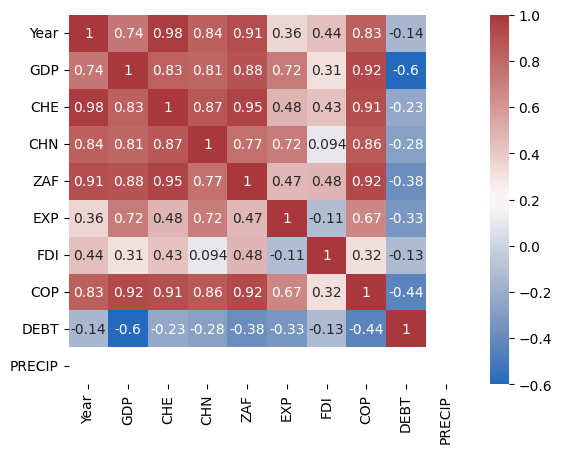

In [3081]:
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', annot=True)

# RANDOM DATA CHECK

In [3082]:
# df.drop(labels=['PRECIP', 'Year'], axis=1, inplace=True)

In [3083]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1969.0,458.981651,3657.207942,100.308139,890.922089,5.716680e+09,3.481361,1467.340000,123.888918,1020.0
1,1970.0,413.904675,4044.420682,113.346243,952.352188,5.716680e+09,0.532207,1415.700000,46.699932,1020.0
2,1971.0,372.144072,4834.740494,118.842492,1020.439836,5.716680e+09,0.509297,1081.416667,53.489928,1020.0
3,1972.0,409.781146,5884.775241,132.097410,1038.394075,5.716680e+09,1.548801,1057.675000,52.905974,1020.0
4,1973.0,517.630055,7855.918870,157.339888,1369.161600,5.716680e+09,1.314570,1785.358333,45.890767,1020.0


In [3084]:
# df['Year'] = df['Year'].astype('string')

In [3085]:
# df = df[(df["Year"] >= 2020) & (df['Year'] <= 2023)]


In [3086]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
scaled = sc.fit_transform(df)
new_df = pd.DataFrame(scaled, columns=df.columns)

In [3087]:
df.dtypes

Year      float64
GDP       float64
CHE       float64
CHN       float64
ZAF       float64
EXP       float64
FDI       float64
COP       float64
DEBT      float64
PRECIP    float64
dtype: object

# 5 ПОСТРОЕНИЕ МОДЕЛЕЙ

## 5.1 ВРУЧНУЮ

## 5.2 С помощью библотек

In [3088]:
df.rename({
    'index': 'Year',
    'ZMB GDP growth (annual %)': 'GDP',
    'CHE GDP growth (annual %)': 'CHE',
    'CHN GDP growth (annual %)': 'CHN',
    'ZAF GDP growth (annual %)': 'ZAF',
    'Exports of goods and services (current US$)': 'EXP',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Copper ($/mt)': 'COP',
    'External debt stocks (% of GNI)': 'DEBT',
    # 'exchange_rate': 'EXR',
    'Average precipitation in depth (mm per year)': 'PRECIP'

}, axis=1, inplace=True)

In [3089]:
df.columns

Index(['Year', 'GDP', 'CHE', 'CHN', 'ZAF', 'EXP', 'FDI', 'COP', 'DEBT',
       'PRECIP'],
      dtype='str')

pick dependent and independent variables

In [3090]:
df.tail()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
50,2019.0,1258.986198,84121.931030,10342.900952,6533.711210,8.073235e+09,2.350919,6010.145000,128.346607,1020.0
51,2020.0,951.644317,85897.784334,10627.463799,5580.603831,8.473998e+09,1.351906,6173.770833,167.518099,1020.0
52,2021.0,1127.160779,93664.773670,12887.435724,6828.756246,1.153788e+10,1.784078,9317.050000,133.551637,1020.0
53,2022.0,1447.123101,94394.510680,12970.605641,6534.248678,1.172209e+10,-0.223287,8822.365833,103.673946,1020.0
54,2023.0,1330.727806,100623.549627,12951.178240,6034.272090,1.126453e+10,2.324653,8490.290833,110.675742,1020.0


In [3091]:
new_df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,-1.700840,-0.660558,-1.436690,-0.698811,-1.464994,0.01913,0.042189,-0.823174,-0.002144,0.0
1,-1.637846,-0.759958,-1.423534,-0.695500,-1.436252,0.01913,-1.128998,-0.843377,-0.941864,0.0
2,-1.574852,-0.852044,-1.396683,-0.694105,-1.404394,0.01913,-1.138096,-0.974158,-0.859200,0.0
3,-1.511858,-0.769051,-1.361008,-0.690739,-1.395993,0.01913,-0.725281,-0.983447,-0.866310,0.0
4,-1.448864,-0.531232,-1.294038,-0.684331,-1.241231,0.01913,-0.818300,-0.698755,-0.951715,0.0


In [3092]:
X = new_df[['COP', 'CHN', 'EXP', 'FDI', 'DEBT']]
# , 'FDI', 'CHN', 'CHE', 'ZAF', 'EXP'
# X = new_df[['EXP']]
Y = new_df[['GDP']]

In [3093]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)
# print(X_scaled)

In [3094]:
X.describe()

,COP,CHN,EXP,FDI,DEBT
count,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01
mean,-1.170781e-16,-1.695613e-16,1.534126e-16,1.281803e-16,-1.095084e-16
std,1.009217e+00,1.009217e+00,1.009217e+00,1.009217e+00,1.009217e+00
min,-9.834465e-01,-6.988106e-01,-1.613463e+00,-1.720819e+00,-1.293860e+00
25%,-7.808290e-01,-6.697432e-01,-3.547171e-01,-7.992530e-01,-8.252030e-01
50%,-5.047843e-01,-5.431653e-01,1.912968e-02,-2.241780e-01,-2.482467e-01
75%,9.853630e-01,3.582667e-01,3.021973e-01,5.751282e-01,6.286553e-01
max,2.247863e+00,2.568898e+00,2.034693e+00,2.473803e+00,3.541225e+00


train test split

In [3095]:
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.10, random_state=42)


In [3096]:
split_point = int(len(df) * 0.2)
X_train, X_test = X[:split_point], X[split_point:]
Y_train, Y_test = Y[:split_point], Y[split_point:]

Initialize the model

In [3097]:
X_test

,COP,CHN,EXP,FDI,DEBT
11,-0.543542,-0.674731,0.019130,-0.709575,-0.408834
12,-0.715738,-0.674153,0.019130,-1.720819,-0.382220
13,-0.818048,-0.672554,0.019130,-0.940262,-0.283767
14,-0.774432,-0.666932,0.019130,-1.033034,-0.025364
15,-0.858393,-0.660502,0.019130,-1.089182,0.359277
16,-0.842718,-0.649377,0.019130,-0.432363,1.240444
17,-0.859776,-0.652567,0.019130,-0.665118,3.541225
18,-0.699872,-0.660232,0.019130,-0.034274,2.595755
19,-0.379390,-0.652166,0.019130,-0.346704,0.945661
20,-0.282859,-0.645208,0.019130,0.287056,0.713353


### 5.2.1 [Ridge](https://www.geeksforgeeks.org/machine-learning/ml-ridge-regressor-using-sklearn/)

In [3098]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
ridge = RidgeCV(alphas = [0.1, 1.0, 10.0], cv=5)
ridge.fit(X_train, Y_train)
y_pred = ridge.predict(X_test)

print("Best alpha selected:", ridge.alpha_)
print("Model score (R^2):", r2_score(Y_test, y_pred))

Best alpha selected: 0.1
Model score (R^2): 0.6836324043187267


In [3099]:
print("Intercept: ", ridge.intercept_)
print("Coefficients: ", ridge.coef_)


Intercept:  [0.01675329]
Coefficients:  [ 6.61416248e-01  5.44924027e-02  5.23431306e-32 -4.81827462e-02
  1.09404000e-01]


In [3100]:
from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("R-squared:", r2_score(Y_test, y_pred))
# print(ridge.score(X_test, Y_test)) # alt. way to get the r^2

Mean Squared Error: 0.35867925069533446
R-squared: 0.6836324043187267


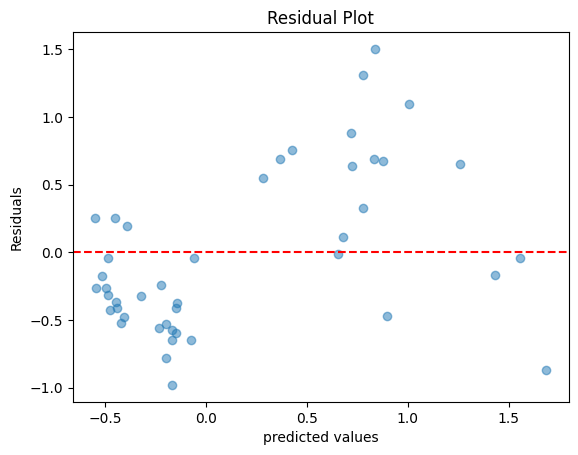

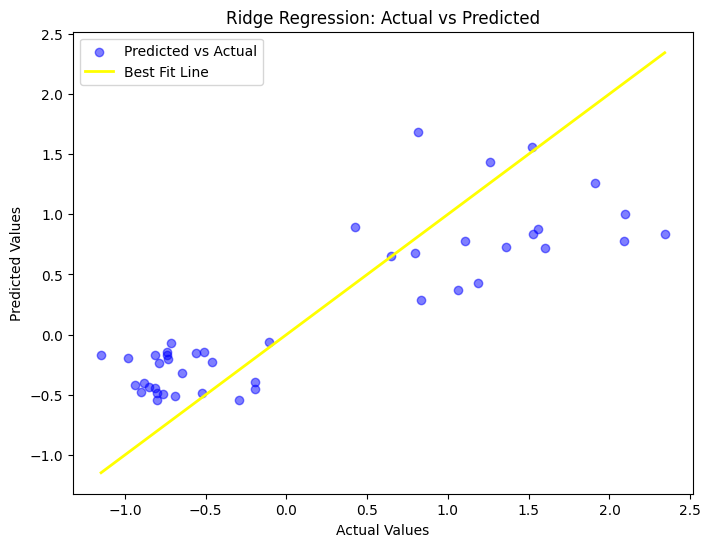

In [3101]:
import matplotlib.pyplot as pp
y_test = Y_test
y_pred = y_pred.reshape(len(y_pred), 1)

residuals = y_test - y_pred
pp.scatter(y_pred, residuals, alpha=0.5)
pp.xlabel('predicted values')
pp.ylabel('Residuals')
pp.title('Residual Plot')
pp.axhline(y=0, color='red', linestyle='--')
pp.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='yellow', linewidth=2, label='Best Fit Line')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [3102]:
y_pred.shape

(44, 1)

In [3103]:
type(y_pred)

numpy.ndarray

In [3104]:
y_pred.shape

(44, 1)

### 5.1.2 Линейнная

In [3105]:
model = LinearRegression()
model.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


finding intercept and slopes

In [3106]:
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

Intercept:  [6.81817859]
Coefficients:  [[8.54557092e-01 9.69203995e+00 8.88178420e-16 4.74022449e-02
  3.67574990e-02]]


Make predictions

In [3107]:
y_pred = model.predict(X_test)

In [3108]:
y_pred.shape

(44, 1)

In [3109]:
from sklearn.metrics import mean_squared_error, r2_score

In [3110]:
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("R-squared:", r2_score(Y_test, y_pred))

Mean Squared Error: 173.80439897730682
R-squared: -152.3015353318695


In [3111]:
result = model.score(X_test, Y_test)
result

-152.3015353318695

In [3112]:
new_df.shape

(55, 10)

In [3113]:
df.corr()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
Year,1.000000,0.739531,0.976621,0.837334,0.906956,0.355128,0.438569,0.832756,-0.144519,NaN
GDP,0.739531,1.000000,0.829460,0.810112,0.883085,0.723285,0.308759,0.918730,-0.600412,NaN
CHE,0.976621,0.829460,1.000000,0.869978,0.945917,0.477122,0.426262,0.905637,-0.225505,NaN
CHN,0.837334,0.810112,0.869978,1.000000,0.767870,0.718381,0.093930,0.860943,-0.280452,NaN
ZAF,0.906956,0.883085,0.945917,0.767870,1.000000,0.472233,0.475801,0.920312,-0.375975,NaN
EXP,0.355128,0.723285,0.477122,0.718381,0.472233,1.000000,-0.112824,0.671335,-0.328757,NaN
FDI,0.438569,0.308759,0.426262,0.093930,0.475801,-0.112824,1.000000,0.316346,-0.127015,NaN
COP,0.832756,0.918730,0.905637,0.860943,0.920312,0.671335,0.316346,1.000000,-0.437873,NaN
DEBT,-0.144519,-0.600412,-0.225505,-0.280452,-0.375975,-0.328757,-0.127015,-0.437873,1.000000,NaN
PRECIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plots

In [3114]:
y_pred.shape

(44, 1)

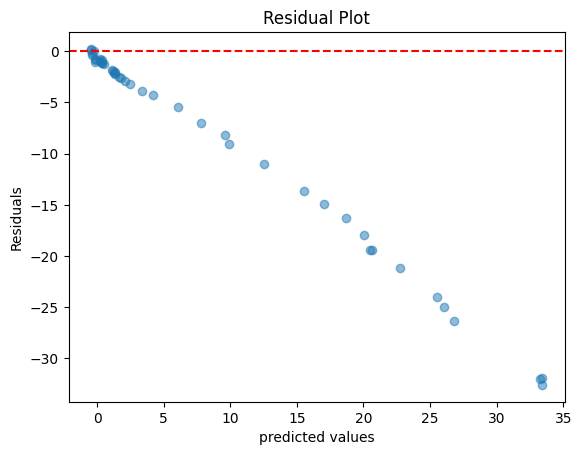

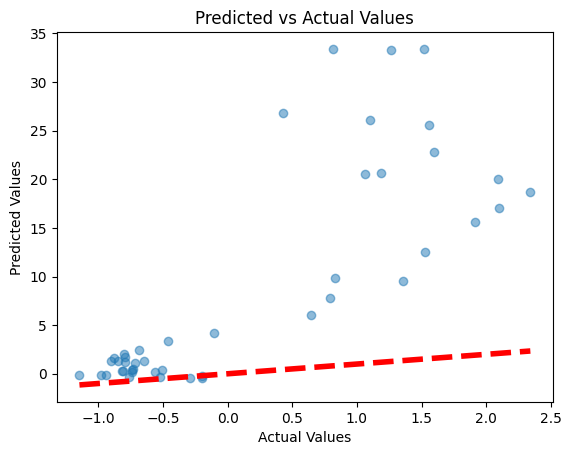

In [3115]:
import matplotlib.pyplot as pp
y_test = Y_test
residuals = y_test - y_pred
pp.scatter(y_pred, residuals, alpha=0.5)
pp.xlabel('predicted values')
pp.ylabel('Residuals')
pp.title('Residual Plot')
pp.axhline(y=0, color='red', linestyle='--')
pp.show()

# Predicted vs Actual Plot
pp.scatter(y_test, y_pred, alpha=0.5)
pp.xlabel('Actual Values')
pp.ylabel('Predicted Values')
pp.title('Predicted vs Actual Values')
pp.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
pp.show()

In [3116]:
# # Source - https://stackoverflow.com/a/68716388
# # Posted by Syed Habeeb Ullah Quadri
# # Retrieved 2026-05-13, License - CC BY-SA 4.0

# import matplotlib.pyplot as plt
# from importlib import reload
# plt=reload(plt)


# y_test = Y_test
# # Residual Plot
# residuals = y_test - y_pred
# plt.scatter(y_pred, residuals, alpha=0.5)
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals')
# plt.title('Residual Plot')
# plt.axhline(y=0, color='red', linestyle='--')
# plt.show()

# # Predicted vs Actual Plot
# plt.scatter(y_test, y_pred, alpha=0.5)
# plt.xlabel('Actual Values')
# plt.ylabel('Predicted Values')
# plt.title('Predicted vs Actual Values')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
# plt.show()

# RADNOM STUFF

<Axes: >

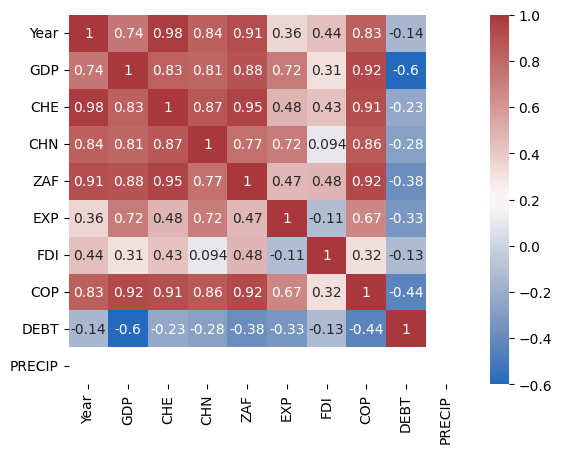

In [3117]:
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', annot=True)

In [3118]:
dfdf = pd.read_csv("../data/raw_merged_2.csv")

In [3119]:
dfdf.head(10)

,Unnamed: 0,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,0,1960.0,221.559849,1954.311321,89.715075,532.147504,NaN,NaN,678.755833,NaN,NaN
1,1,1961.0,209.693206,2155.449969,75.965501,545.657512,NaN,NaN,633.084167,NaN,1020.0
2,2,1962.0,202.281031,2330.477365,71.061685,563.423009,NaN,NaN,645.143333,NaN,1020.0
3,3,1963.0,203.219451,2508.474307,74.468154,604.536855,NaN,NaN,645.950833,NaN,1020.0
4,4,1964.0,229.979246,2734.930090,85.661107,645.873376,NaN,NaN,969.753333,NaN,1020.0
5,5,1965.0,287.425476,2865.244848,98.668169,684.621228,NaN,NaN,1292.844167,NaN,1020.0
6,6,1966.0,325.025847,3044.845604,104.506464,721.753759,NaN,NaN,1531.513333,NaN,1020.0
7,7,1967.0,340.579940,3237.273152,96.761448,778.839336,NaN,NaN,1134.772500,NaN,1020.0
8,8,1968.0,387.087289,3413.493582,91.645458,817.128341,NaN,NaN,1241.952500,NaN,1020.0
9,9,1969.0,458.981651,3657.207942,100.308139,890.922089,NaN,NaN,1467.340000,NaN,1020.0
